In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, brier_score_loss

# Load data
df = pd.read_csv("llm_reliability_dataset_final.csv")

# Feature selection
features = [
    "mean_entropy",
    "max_entropy",
    "entropy_variance",
    "mean_logprob",
    "min_logprob",
    "logprob_variance",
    "answer_length_tokens",
    "band"
]
# Optional (recommended)
df["band"] = df["band"].map({"1B": 1, "3B": 3, "7B": 7})
features.append("band")

X = df[features]
y = df["label_hybrid"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scaling for Logistic
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Models
log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
rf_model = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)

# Train
log_model.fit(X_train_s, y_train)
rf_model.fit(X_train, y_train)

# Predict probabilities
log_probs = log_model.predict_proba(X_test_s)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
def evaluate(name, probs):
    print(f"{name}")
    print("ROC-AUC:", roc_auc_score(y_test, probs))
    print("Brier:", brier_score_loss(y_test, probs))
    print("-"*25)

evaluate("Logistic", log_probs)
evaluate("Random Forest", rf_probs)

Logistic
ROC-AUC: 0.6041395348837209
Brier: 0.24881610265139184
-------------------------
Random Forest
ROC-AUC: 0.5763720930232558
Brier: 0.09825945993337536
-------------------------


# Isotonic Calibration

In [3]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_rf = CalibratedClassifierCV(
    rf_model,
    method="isotonic",
    cv=5
)

calibrated_rf.fit(X_train, y_train)

calib_probs = calibrated_rf.predict_proba(X_test)[:, 1]

In [4]:
from sklearn.metrics import roc_auc_score, brier_score_loss

print("Calibrated RF")
print("ROC-AUC:", roc_auc_score(y_test, calib_probs))
print("Brier:", brier_score_loss(y_test, calib_probs))

Calibrated RF
ROC-AUC: 0.6046279069767442
Brier: 0.09204592619483846


# Visual

In [6]:
import pandas as pd

df_eval = pd.DataFrame({
    "y_true": y_test,
    "probs": calib_probs
})
bins = [0, 0.05, 0.1, 0.15, 0.2, 1.0]

df_eval["bucket"] = pd.cut(df_eval["probs"], bins=bins)
bucket_acc = df_eval.groupby("bucket")["y_true"].mean()
bucket_count = df_eval.groupby("bucket")["y_true"].count()

print(bucket_acc)
print(bucket_count)

bucket
(0.0, 0.05]    0.000000
(0.05, 0.1]    0.104575
(0.1, 0.15]    0.098425
(0.15, 0.2]    0.243243
(0.2, 1.0]     0.000000
Name: y_true, dtype: float64
bucket
(0.0, 0.05]     35
(0.05, 0.1]    153
(0.1, 0.15]    254
(0.15, 0.2]     37
(0.2, 1.0]       1
Name: y_true, dtype: int64


C:\Users\hp\AppData\Local\Temp\ipykernel_7860\761074031.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_acc = df_eval.groupby("bucket")["y_true"].mean()
C:\Users\hp\AppData\Local\Temp\ipykernel_7860\761074031.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_count = df_eval.groupby("bucket")["y_true"].count()


The model is well-calibrated in the low-confidence regime but unreliable in higher confidence ranges due to limited predictive signal and sample sparsity.

The proposed system demonstrates strong calibration in the low-confidence regime, effectively identifying hallucinated responses. However, it exhibits limited discriminative power in higher confidence ranges, indicating that uncertainty signals are more effective for risk detection than correctness confirmation.

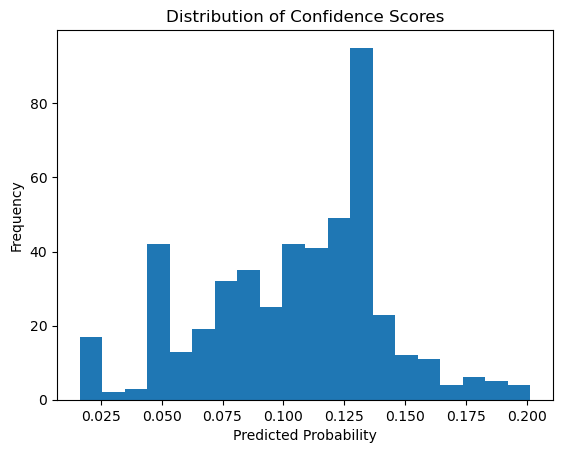

: 

In [ ]:
import matplotlib.pyplot as plt

plt.hist(calib_probs, bins=20)
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Distribution of Confidence Scores")
plt.show()